In [1]:
import numpy as np
import pandas as pd 

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import momepy
import os
import glob

c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Creating Samples

<>:124: SyntaxWarning: invalid escape sequence '\S'
<>:124: SyntaxWarning: invalid escape sequence '\S'
C:\Users\mmosh\AppData\Local\Temp\ipykernel_27348\671410882.py:124: SyntaxWarning: invalid escape sequence '\S'
  sample_output = f"{output_dir}\SamplePop.shp"
C:\Users\mmosh\AppData\Local\Temp\ipykernel_27348\671410882.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  Population['area'] = Population.geometry.area
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35043010601 of field tractsNM_9 of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35043010601 of field popul_bytr of feature 0 not successfully written. Possibly due to too larger num

  tractsNMnu tractsNM_1 tractsNM_2 tractsNM_3          tractsNM_4 tractsNM_5  \
0         35        001     003100         31     Census Tract 31      G5020   
1         35        001     004716      47.16  Census Tract 47.16      G5020   
2         35        001     004729      47.29  Census Tract 47.29      G5020   
3         35        001     003002      30.02  Census Tract 30.02      G5020   
4         35        001     002401      24.01  Census Tract 24.01      G5020   

   tractsNM_6  tractsNM_7          tractsNM_8    tractsNM_9  ...  popul_b_52  \
0    0.098744    0.000443  14000US35001003100  3.500100e+10  ...          62   
1    0.142304    0.000406  14000US35001004716  3.500100e+10  ...          40   
2    0.114773    0.000500  14000US35001004729  3.500100e+10  ...         153   
3    0.085818    0.000397  14000US35001003002  3.500100e+10  ...         119   
4    0.091297    0.000357  14000US35001002401  3.500100e+10  ...         123   

   popul_b_53  popul_b_54  popul_b_55 

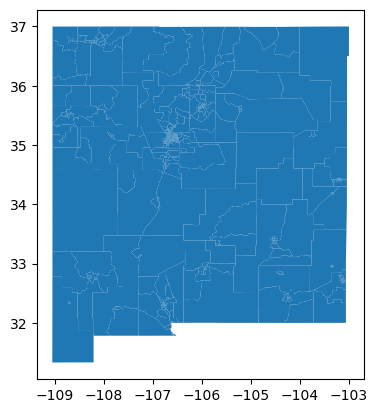

In [2]:
Population = gpd.read_file(r"C:\Users\mmosh\Research-Project\Population\popul_bytracts2018.shp").explode(
                ignore_index=True, index_parts=False
           )[["geometry"]] #explod here means we break multilines in GIS into multiple simple lines.
    
Population['area'] = Population.geometry.area
Population.plot()
# Possibly don't need what is above.
    
tracts = gpd.read_file("/Users/mmosh/Research-Project/Population/popul_bytracts2018.shp")

Sample1 = tracts[tracts['popul_by_1'] == 4883]

Sample1.to_file(r"C:\Users\mmosh\Research-Project\Population\Samples\S1_Pop.shp")

Sample2 = tracts[tracts['popul_by_1'] == 6839]

Sample2.to_file(r"C:\Users\mmosh\Research-Project\Population\Samples\S2_Pop.shp")
#Sample2.plot(edgecolor='black', color='lightgreen')

Sample3 = tracts[tracts['popul_by_1'] == 6809]

Sample3.to_file(r"C:\Users\mmosh\Research-Project\Population\Samples\S3_Pop.shp")
#Sample3.plot(edgecolor='black', color='lightgreen')

Sample4 = tracts[tracts['popul_by_1'] == 4303]

Sample4.to_file(r"C:\Users\mmosh\Research-Project\Population\Samples\S4_Pop.shp")
#Sample4.plot(edgecolor='black', color='lightgreen')

Sample5 = tracts[tracts['popul_by_1'] == 3573]

Sample5.to_file(r"C:\Users\mmosh\Research-Project\Population\Samples\S5_Pop.shp")
#Sample5.plot(edgecolor='black', color='lightgreen')

Sample6 = tracts[tracts['popul_by_1'] == 3510]

Sample6.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S6_Pop.shp')
#Sample6.plot(edgecolor='black', color='lightgreen')

Sample7 = tracts[tracts['popul_by_1'] == 6541]

Sample7.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S7_Pop.shp')
#Sample7.plot(edgecolor='black', color='lightgreen')

Sample8 = tracts[tracts['popul_by_1'] == 5195]

Sample8.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S8_Pop.shp')
#Sample8.plot(edgecolor='black', color='lightgreen')

Sample9 = tracts[tracts['popul_by_1'] == 4814]

Sample9.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S9_Pop.shp')
#Sample9.plot(edgecolor='black', color='lightgreen')

Sample10 = tracts[tracts['popul_by_1'] == 2699]

Sample10.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S10_Pop.shp')
#Sample10.plot(edgecolor='black', color='lightgreen')

Sample11 = tracts[tracts['popul_by_1'] == 1968]

Sample11.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S11_Pop.shp')
#Sample11.plot(edgecolor='black', color='lightgreen')

Sample12 = tracts[(tracts['popul_by_1'] == 3789) & (tracts['popul_by_2'] == 768)]

Sample12.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S12_Pop.shp')
#Sample12.plot(edgecolor='black', color='lightgreen')

Sample13 = tracts[tracts['popul_by_1'] == 4391]

Sample13.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S13_Pop.shp')
#Sample13.plot(edgecolor='black', color='red')

Sample14 = tracts[tracts['popul_by_1'] == 5270]

Sample14.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S14_Pop.shp')
#Sample14.plot(edgecolor='black', color='red')

Sample15 = tracts[tracts['popul_by_1'] == 3068]

Sample15.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S15_Pop.shp')
#Sample15.plot(edgecolor='black', color='red')

Sample16 = tracts[tracts['popul_by_1'] == 9017]

Sample16.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S16_Pop.shp')
#Sample16.plot(edgecolor='black', color='red')

Sample17 = tracts[tracts['popul_by_1'] == 2790] 

Sample17.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S17_Pop.shp')
#Sample17.plot(edgecolor='black', color='red')

Sample18 = tracts[tracts['popul_by_1'] == 5604]

Sample18.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S18_Pop.shp')
#Sample18.plot(edgecolor='black', color='red')

Sample19 = tracts[tracts['popul_by_1'] == 3322]

Sample19.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S19_Pop.shp')
#Sample19.plot(edgecolor='black', color='red')

Sample20 = tracts[tracts['popul_by_1'] == 4130]

Sample20.to_file(r'C:\Users\mmosh\Research-Project\Population\Samples\S20_Pop.shp')
#Sample20.plot(edgecolor='black', color='red')

files = glob.glob("C:\\Users\\mmosh\\Research-Project\\Population\\Samples\\*.shp")
gdfs = [gpd.read_file(f) for f in files]

# Standardize CRS to NAD83 (EPSG:4269) for all GeoDataFrames
# This ensures compatibility before concatenation. This was done using the Copilot AI assistant in VS Code.
common_crs = "EPSG:4269"  # NAD83; change to "EPSG:4326" for WGS84 if preferred
gdfs = [gdf.to_crs(common_crs) if gdf.crs != common_crs else gdf for gdf in gdfs]

merged = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)

output_dir = r"C:\Users\mmosh\Research-Project\Population\Samples"
sample_output = f"{output_dir}\SamplePop.shp"
SamplePop = merged.to_file(sample_output)
SamplePop = gpd.read_file(sample_output)
print(SamplePop.head())



Adding in Land Use Data.

<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\L'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\L'
C:\Users\mmosh\AppData\Local\Temp\ipykernel_27348\2008319211.py:45: SyntaxWarning: invalid escape sequence '\m'
  Espanola_LandUse = gpd.read_file("C:\\Users\mmosh\\Research-Project\\Land Use\\aztec.shp")
C:\Users\mmosh\AppData\Local\Temp\ipykernel_27348\2008319211.py:55: SyntaxWarning: invalid escape sequence '\L'
  LU_output = f"{LU_dir}\LandUse.shp"
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 2000000201 of field ALBUQ_ID of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 2000000201 of field ALBUQ_ID of feature 1 not successfully written. Possibly due to too larger number wi

      LUCODE_0  LUCODE_11  LUCODE_12  LUCODE_13  LUCODE_14  LUCODE_16  \
0          1.0        0.0        0.0        0.0        0.0        0.0   
1          1.0        0.0        0.0        0.0        0.0        0.0   
2          0.0        0.0        0.0        0.0        0.0        0.0   
3          0.0        0.0        0.0        0.0        0.0        0.0   
4          0.0        0.0        0.0        0.0        0.0        0.0   
...        ...        ...        ...        ...        ...        ...   
4856       0.0        1.0        0.0        0.0        0.0        0.0   
4857       0.0        0.0        0.0        0.0        0.0        0.0   
4858       0.0        0.0        0.0        0.0        0.0        0.0   
4859       0.0        0.0        0.0        0.0        0.0        0.0   
4860       1.0        0.0        0.0        0.0        0.0        0.0   

      LUCODE_17  LUCODE_21  LUCODE_22  LUCODE_23  ...  LUCODE_42  LUCODE_43  \
0           0.0        0.0        0.0       

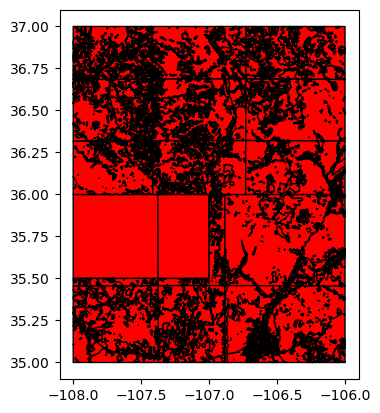

In [3]:
#Adding Land Use data to sample populations base layer. 
from json import encoder

from sklearn.preprocessing import OneHotEncoder
land_use_categories = {
    11: "Residential",
    12: "Commercial and Services",
    13: "Industrial",
    14: "Transportation, Communications and Utilities",
    15: "Industrial and Commercial Complexes",
    16: "Mixed Urban or Built-up Land",
    17: "Other Urban or Built-up Land",
    21: "Cropland and Pasture",
    22: "Orchards, Groves, Vineyards, Nurseries, and Ornamental Horticultural Areas",
    23: "Confined Feeding Operations",
    24: "Other Agricultural Land",
    31: "Herbaceous Rangeland",
    32: "Shrub and Brush Rangeland",
    33: "Mixed Rangeland",
    41: "Deciduous Forest Land",
    42: "Evergreen Forest Land",
    43: "Mixed Forest Land",
    51: "Streams and Canals",
    52: "Lakes",
    53: "Reservoirs",
    54: "Bays and Estuaries",
    61: "Forested Wetland",
    62: "Nonforested Wetland",
    71: "Dry Salt Flats",
    72: "Beaches",
    73: "Sandy Areas Other than Beaches",
    74: "Bare Exposed Rock",
    75: "Strip Mines, Quarries, and Gravel Pits",
    76: "Transitional Areas",
    77: "Mixed Barren Land",
    81: "Shrub and Brush Tundra",
    82: "Herbaceous Tundra",
    83: "Bare Ground",
    84: "Wet Tundra 85 Mixed Tundra",
    91: "Perennial Ice/Snow",
    92: "Glaciers"
}

Albaquerque_LandUse = gpd.read_file("C:\\Users\\mmosh\\Research-Project\\Land Use\\Albuq.shp")
Espanola_LandUse = gpd.read_file("C:\\Users\mmosh\\Research-Project\\Land Use\\aztec.shp")

files = glob.glob("C:\\Users\\mmosh\\Research-Project\\Land Use\\*.shp")
gdfs = [gpd.read_file(f) for f in files]

merged = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)
LU_dir = r"C:\Users\mmosh\Research-Project\Land Use\Combined"
LU_output = f"{LU_dir}\LandUse.shp"
merged.to_file(LU_output)

LandUse = gpd.read_file(LU_output)
LandUse.plot(edgecolor='black', color='red')

L_U = pd.DataFrame({
    "LUCODE": LandUse["LUCODE"]
})

encoder1= OneHotEncoder(sparse_output=False)
encoded_array1= encoder1.fit_transform(L_U[["LUCODE"]])

encoded_df = pd.DataFrame(
    encoded_array1,
    columns=encoder1.get_feature_names_out(["LUCODE"])
)

print(encoded_df)



Overlaying Population and Land Use Data.

In [4]:
LandUse = LandUse.to_crs(SamplePop.crs)
joined1 = gpd.sjoin(SamplePop, LandUse, how="inner", predicate='intersects')
dominant = joined1.loc[
    joined1.groupby("LUCODE")["geometry"].apply(lambda x: x.area.idxmax())
]
print(joined1.head())
joined1.to_file(r"C:\Users\mmosh\Research-Project\Tabulation\J1\joined_output.shp")

#This is for when training and testing the data. 
#from sklearn.preprocessing import OneHotEncoder

#encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

#X_train_encoded = encoder.fit_transform(X_train[["categorical_column"]])

#X_test_encoded = encoder.transform(X_test[["categorical_column"]])

C:\Users\mmosh\AppData\Local\Temp\ipykernel_27348\3835803028.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  joined1.groupby("LUCODE")["geometry"].apply(lambda x: x.area.idxmax())


  tractsNMnu tractsNM_1 tractsNM_2 tractsNM_3       tractsNM_4 tractsNM_5  \
0         35        001     003100         31  Census Tract 31      G5020   
0         35        001     003100         31  Census Tract 31      G5020   
0         35        001     003100         31  Census Tract 31      G5020   
0         35        001     003100         31  Census Tract 31      G5020   
0         35        001     003100         31  Census Tract 31      G5020   

   tractsNM_6  tractsNM_7          tractsNM_8    tractsNM_9  ...  popul_b_60  \
0    0.098744    0.000443  14000US35001003100  3.500100e+10  ...          35   
0    0.098744    0.000443  14000US35001003100  3.500100e+10  ...          35   
0    0.098744    0.000443  14000US35001003100  3.500100e+10  ...          35   
0    0.098744    0.000443  14000US35001003100  3.500100e+10  ...          35   
0    0.098744    0.000443  14000US35001003100  3.500100e+10  ...          35   

                                            geometry  in

C:\Users\mmosh\AppData\Local\Temp\ipykernel_27348\3835803028.py:7: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  joined1.to_file(r"C:\Users\mmosh\Research-Project\Tabulation\J1\joined_output.shp")
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35001003100 of field tractsNM_9 of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35001003100 of field popul_bytr of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Val

Adding Flood Risk Data. This Data will be used as the target.

In [9]:
files1 = glob.glob(r"C:\Users\mmosh\Research-Project\Flood Risk\Simplified FR\*.shp")
gdfs1 = [gpd.read_file(f) for f in files1]

merged = gpd.GeoDataFrame(
    pd.concat(gdfs1, ignore_index=True),
    crs=gdfs1[0].crs
)
FR_dir = r"C:\Users\mmosh\Research-Project\Flood Risk\Combined FR"
FR_output = f"{FR_dir}\FloodRisk.shp"
merged.to_file(FR_output)

nfhl = gpd.read_file(r"C:\Users\mmosh\Research-Project\Flood Risk\Combined FR\FloodRisk.shp")
nfhl = nfhl.to_crs(epsg=4326)

for gdf in [joined1, nfhl]:
    for col in ["index_right", "index_left"]:
        if col in gdf.columns:
            gdf.drop(columns=col, inplace=True)
            
def map_flood_risk(row):
    zone = row["FLD_ZONE"]
    subtype = row.get("ZONE_SUBTY", None)

    if zone in ["AE", "VE", "A", "AO", "AH"]:
        return "high"

    elif zone == "X":
        if subtype is not None and "0.2" in str(subtype):
            return "moderate"   # shaded X
        else:
            return "low"        # unshaded X

    else:
        return "unknown"
        
base = joined1.copy()
base["LUCODE"] = base.index

joined2 = gpd.overlay(base, nfhl, how="intersection")

# Add risk_group column by applying the function
joined2["risk_group"] = joined2.apply(
    lambda row: (
        "high" if row["FLD_ZONE"] in ["AE", "VE", "A", "AO", "AH"]
        else "moderate" if row["FLD_ZONE"] == "X" and row["ZONE_SUBTY"] is not None and "0.2" in str(row["ZONE_SUBTY"])
        else "low" if row["FLD_ZONE"] == "X"
        else "unknown"
    ),
    axis=1
)

joined2["overlap_area"] = joined2.geometry.area

# Sort so largest overlap comes first
joined2 = joined2.sort_values(by="overlap_area", ascending=False)

# Keep only the largest overlap per base polygon
dominant = joined2.drop_duplicates(subset="LUCODE")

result = base.merge(
    dominant[["LUCODE", "FLD_ZONE", "ZONE_SUBTY", "risk_group"]],
    on="LUCODE",
    how="left"
)

print(result.head())
result.to_file(r"C:\Users\mmosh\Research-Project\Tabulation\J2\joined_output.shp")
df = pd.get_dummies(result, columns=["FLD_ZONE"])
print(result[["FLD_ZONE", "ZONE_SUBTY", "risk_group"]].drop_duplicates())

<>:9: SyntaxWarning: invalid escape sequence '\F'
<>:9: SyntaxWarning: invalid escape sequence '\F'
C:\Users\mmosh\AppData\Local\Temp\ipykernel_27348\1374335660.py:9: SyntaxWarning: invalid escape sequence '\F'
  FR_output = f"{FR_dir}\FloodRisk.shp"
C:\Users\mmosh\AppData\Local\Temp\ipykernel_27348\1374335660.py:39: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4269
Right CRS: EPSG:4326

  joined2 = gpd.overlay(base, nfhl, how="intersection")
C:\Users\mmosh\AppData\Local\Temp\ipykernel_27348\1374335660.py:52: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  joined2["overlap_area"] = joined2.geometry.area


  tractsNMnu tractsNM_1 tractsNM_2 tractsNM_3       tractsNM_4 tractsNM_5  \
0         35        001     003100         31  Census Tract 31      G5020   
1         35        001     003100         31  Census Tract 31      G5020   
2         35        001     003100         31  Census Tract 31      G5020   
3         35        001     003100         31  Census Tract 31      G5020   
4         35        001     003100         31  Census Tract 31      G5020   

   tractsNM_6  tractsNM_7          tractsNM_8    tractsNM_9  ...      AREA  \
0    0.098744    0.000443  14000US35001003100  3.500100e+10  ...  0.000070   
1    0.098744    0.000443  14000US35001003100  3.500100e+10  ...  0.000003   
2    0.098744    0.000443  14000US35001003100  3.500100e+10  ...  0.000047   
3    0.098744    0.000443  14000US35001003100  3.500100e+10  ...  0.000006   
4    0.098744    0.000443  14000US35001003100  3.500100e+10  ...  0.000017   

   PERIMETER  ALBUQ_  ALBUQ_ID  LUCODE  AZTEC_  AZTEC_ID  FLD_ZONE  

c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35001003100 of field tractsNM_9 of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35001003100 of field popul_bytr of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35001003100 of field tractsNM_9 of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35001003100 of field popul_bytr of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\env

    FLD_ZONE                                 ZONE_SUBTY risk_group
0          X  AREA WITH REDUCED FLOOD RISK DUE TO LEVEE        low
9          X               AREA OF MINIMAL FLOOD HAZARD        low
84         X         0.2 PCT ANNUAL CHANCE FLOOD HAZARD   moderate
139        A                                        NaN       high
190        D                                        NaN    unknown


To Help Simplify the Data, Unneeded Columns Will Be Removed. 

In [10]:
Table = joined2[["FLD_ZONE", "LUCODE", "popul_by_1"]]

Table.to_csv("cleaned_training_data.csv", index=False)    
print(Table.columns)      

         

Index(['FLD_ZONE', 'LUCODE', 'popul_by_1'], dtype='str')


Now Data For Flow Rate and Precipitation Will Be Added.

In [7]:
#if Table.loc[3510, "popul_by_1"] == 8970 or Table.loc[6541, "popul_by_1"] == 8970:
#    Table.loc[0, "risk"] = "high"
    

#Table.loc[X:Y, "Precipitation"] = Z #Use this to add precipitation column and input the precipitation data.
#Table.head()

Now we can begin training and testing the model. 

In [8]:
#X = Table.drop(columns=["target"])   # predictors
#y = Table["target"]                 # what you're predicting
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y,
#    test_size=0.2,     # 20% test
#    random_state=42    # reproducibility
#)

#model = RandomForestClassifier()
#model.fit(X_train, y_train)
#from pyexpat import model


#y_pred = model.predict(X_test)
#
#print("Accuracy:", accuracy_score(y_test, y_pred))
#print(classification_report(y_test, y_pred))